## 2. Entrena una red neuronal para que reproduzca las siguientes funciones en el intervalo de [-1,1]. Graficar la solución de la red en conjunto con la gráfica de la función. 

$(a) 3 sin(\pi x)$

$(b) 1 + 2x + 4x^3$

In [163]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, metrics, Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from keras.optimizers import Adam
import numpy as np

In [ ]:
class ModeloFuncion(Sequential):
    def __init__(self,layers=None, name=None):
        super().__init__(layers=layers, name=name)
        self.loss_tracker = metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        """La forma de y debe de tener la forma de la función objetivo"""
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = tf.reduce_mean(tf.square(y_pred - y))

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


## $(a) 3 sin(\pi x)$

In [180]:
model = ModeloFuncion()
model.add(Dense(64,activation='tanh', input_shape=(1,)))
model.add(Dense(64,activation='tanh'))
model.add(Dense(32,activation='tanh'))
model.add(Dense(1))
model.summary()

/home/dracdarktime/miniconda3/envs/tensorflow-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "modelo_funcion_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_108 (Dense)               │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_muestras = 1000
x = tf.random.uniform((num_muestras,1), minval=-1, maxval=1)
y = 3. * tf.math.sin(np.pi*x) #Creamos la función objetivo
model.compile(optimizer=Adam(learning_rate=0.001), metrics=['loss'])
history = model.fit(x=x,y=y,epochs=1000,verbose=0,batch_size=64)

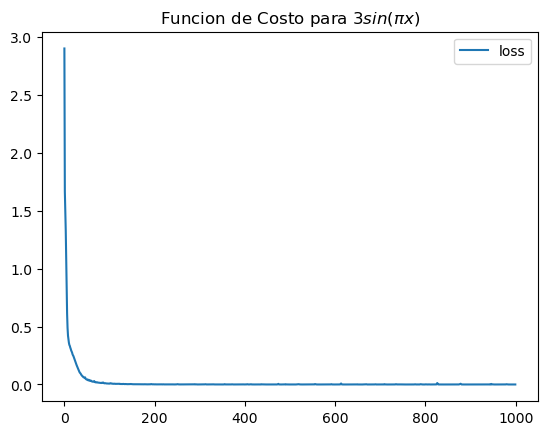

In [183]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $3 sin(\pi x)$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


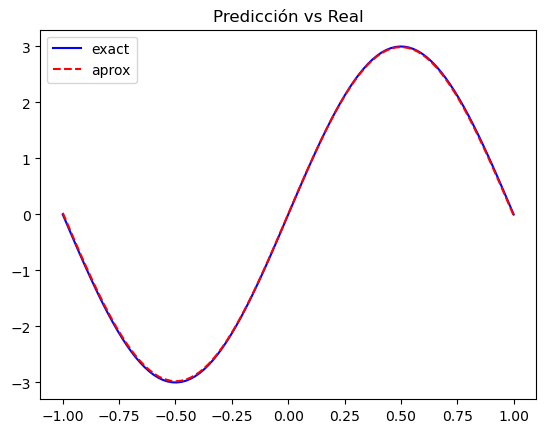

In [184]:
x=tf.linspace(-1,1,100)
y_pred=model.predict(x)
plt.plot(x, 3.*np.sin(np.pi*x), label="exact", color='blue')
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.title("Predicción vs Real")
plt.legend()
plt.show()

## $(b) 1 + 2x + 4x^3$

In [212]:
model2 = ModeloFuncion()
model2.add(Dense(64,activation='relu', input_shape=(1,)))
model2.add(Dense(64,activation='relu'))
model2.add(Dense(32,activation='relu'))
model2.add(Dense(1))
model2.summary()

Model: "modelo_funcion_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_muestras=1000
x = tf.random.uniform((num_muestras,1), minval=-1, maxval=1)
y = 1. + 2.*x + 4.*x**3 #Creamos la función objetivo
model2.compile(optimizer=Adam(learning_rate=0.01), metrics=['loss'])
history = model2.fit(x=x,y=y,epochs=1000,verbose=0, batch_size=64)

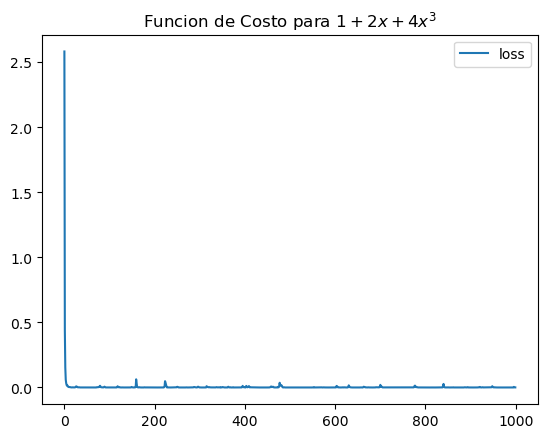

In [214]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $1 + 2x + 4x^3$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step


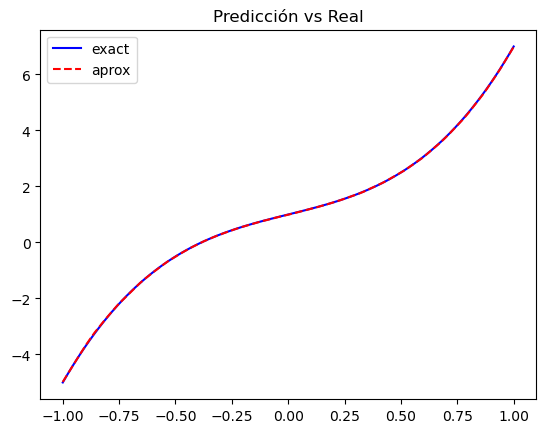

In [215]:
x=tf.linspace(-1,1,100)
y_pred=model2.predict(x)
plt.plot(x, 1 + 2*x + 4*x**3, label="exact", color='blue')
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.title("Predicción vs Real")
plt.legend()
plt.show()